# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-f4e7dd9a-237c-8d0e-9a4b-5318f1776cdc)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: Tesla T4


# 2. Create a sequential CNN model with two alternative APIs

In [3]:
input_1channel = (502, 502, 1)       # 1-channel image
input_3channel = (502, 502, 3)       # 3-channel image

input_dim = input_3channel           # Choose your target dimension for this example
output_dim = 1000                    # The number of output classes (single-label multi-class classification)

## 2.1 Sequential API

In [4]:
model1 = keras.models.Sequential()

# Input layer
model1.add( keras.Input(shape=input_dim) )

# Hidden layer: Feature extractor
model1.add( keras.layers.Conv2D(filters=128, kernel_size=7, activation='relu', padding='valid') )
model1.add( keras.layers.Conv2D(filters=64, kernel_size=5, activation='relu', padding='valid') )
model1.add( keras.layers.MaxPool2D(pool_size=2) )
model1.add( keras.layers.BatchNormalization(axis=-1) )
model1.add( keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same') )
model1.add( keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', strides=2) )
model1.add( keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='valid', strides=2) )
model1.add( keras.layers.BatchNormalization(axis=-1) )

# Convert 2D feature maps to a 1D vector
model1.add( keras.layers.Flatten() )     # Flat the input into a 2D tensor of shape=(batch_size,?)

# Hidden layer: Classifier
model1.add( keras.layers.Dense(1024, activation='relu') )
model1.add( keras.layers.Dropout(0.5) )  # Drop rate = 50%
model1.add( keras.layers.Dense(1024, activation='relu') )
model1.add( keras.layers.Dropout(0.5) )  # Drop rate = 50%
model1.add( keras.layers.Dense(output_dim, activation='softmax' ) )

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 496, 496, 128)  │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 492, 492, 64)   │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 246, 246, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 246, 246, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 246, 246, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 123, 123, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 59536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    60,965,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     1,025,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,290,024 (241.43 MB)

 Trainable params: 63,289,864 (241.43 MB)

 Non-trainable params: 160 (640.00 B)

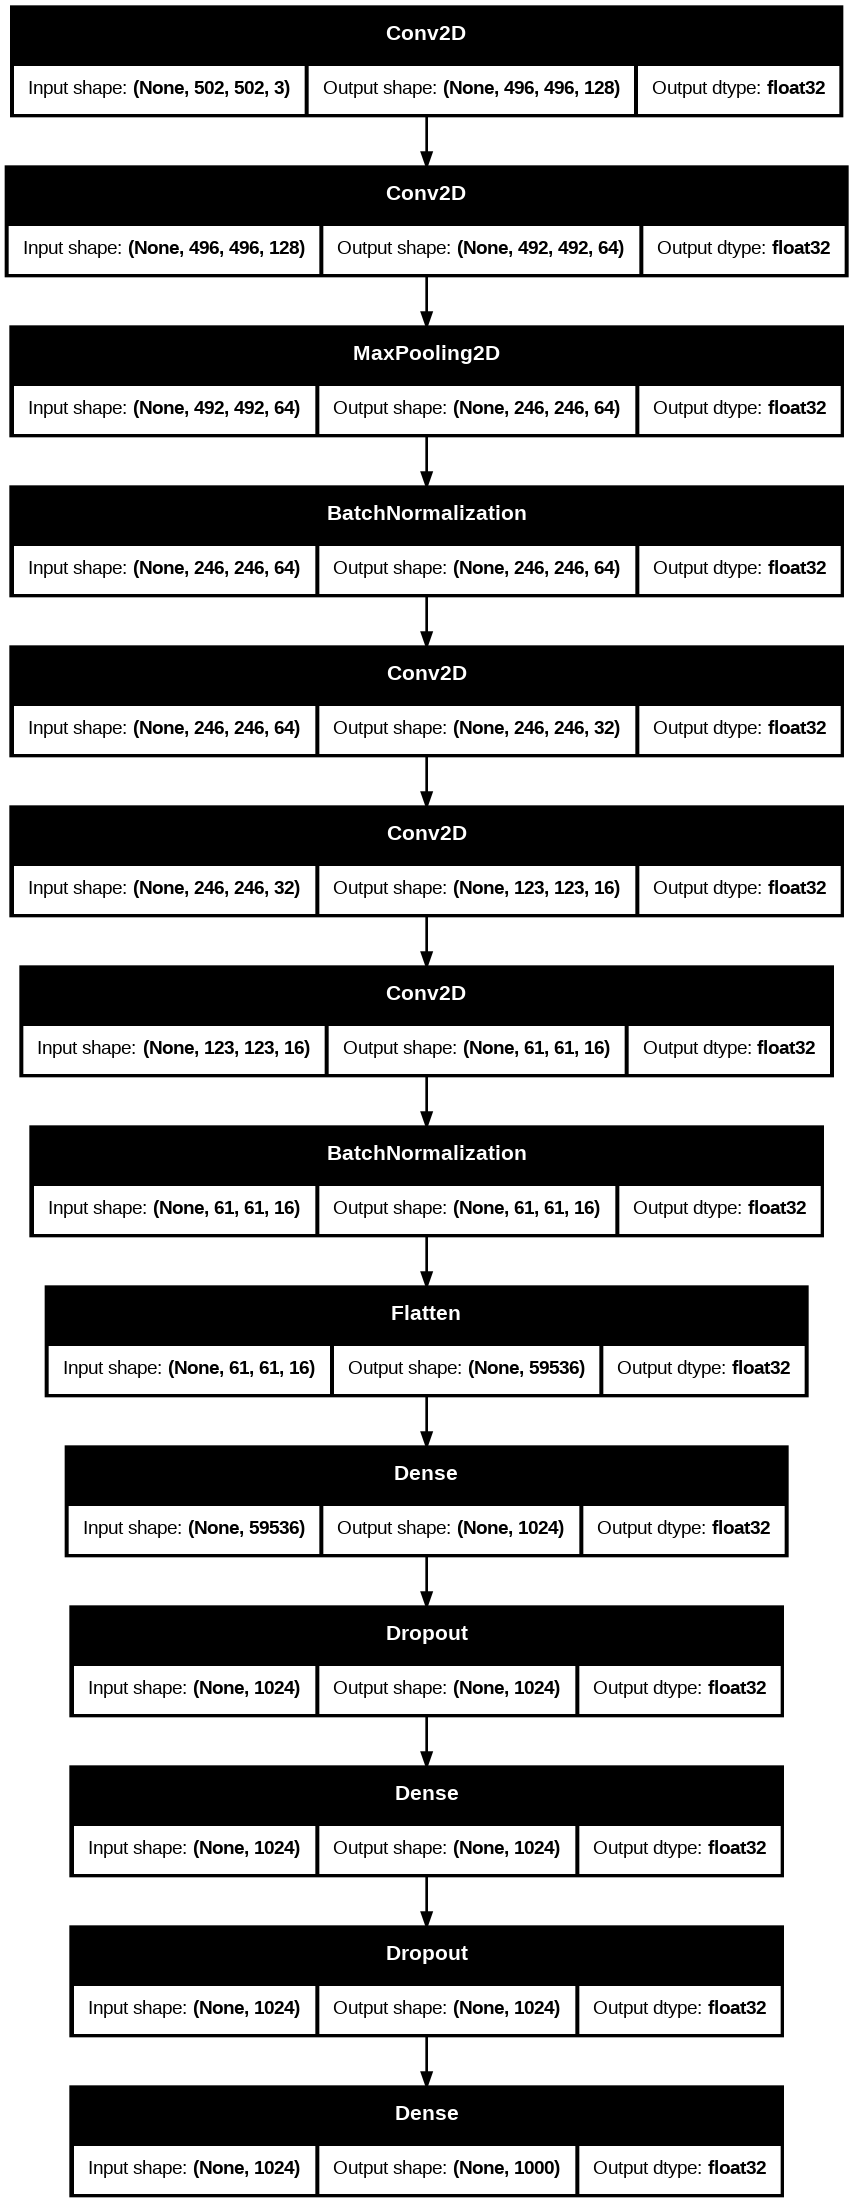

In [5]:
keras.utils.plot_model(model1, to_file='cnn1_sequential.png', show_shapes=True, show_dtype=True, show_layer_names=False, dpi=96)

## 2.2 Functional API

In [6]:
# Input layer
inputs = keras.Input(shape=input_dim)

# Hidden layer: Feature extractor
x = keras.layers.Conv2D(filters=128, kernel_size=7, activation='relu', padding='valid')(inputs)
x = keras.layers.Conv2D(filters=64, kernel_size=5, activation='relu', padding='valid')(x)
x = keras.layers.MaxPool2D(pool_size=2)(x)
x = keras.layers.BatchNormalization(axis=-1)(x)
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='same', strides=2)(x)
x = keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', padding='valid', strides=2)(x)

# Convert 2D feature maps to a 1D vector
x = keras.layers.Flatten()(x)       # Flat the input into a 2D tensor of shape=(batch_size,?)

# Hidden layer: Classifier
x = keras.layers.Dense(1024, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)    # Drop rate = 50%
x = keras.layers.Dense(1024, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)    # Drop rate = 50%
outputs = keras.layers.Dense(output_dim, activation='softmax')(x)

# Construct the model
model2 = keras.models.Model(inputs=inputs, outputs=outputs)

model2.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 502, 502, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 496, 496, 128)  │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 492, 492, 64)   │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 246, 246, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 246, 246, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 246, 246, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 123, 123, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 59536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │    60,965,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │     1,025,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,289,960 (241.43 MB)

 Trainable params: 63,289,832 (241.43 MB)

 Non-trainable params: 128 (512.00 B)

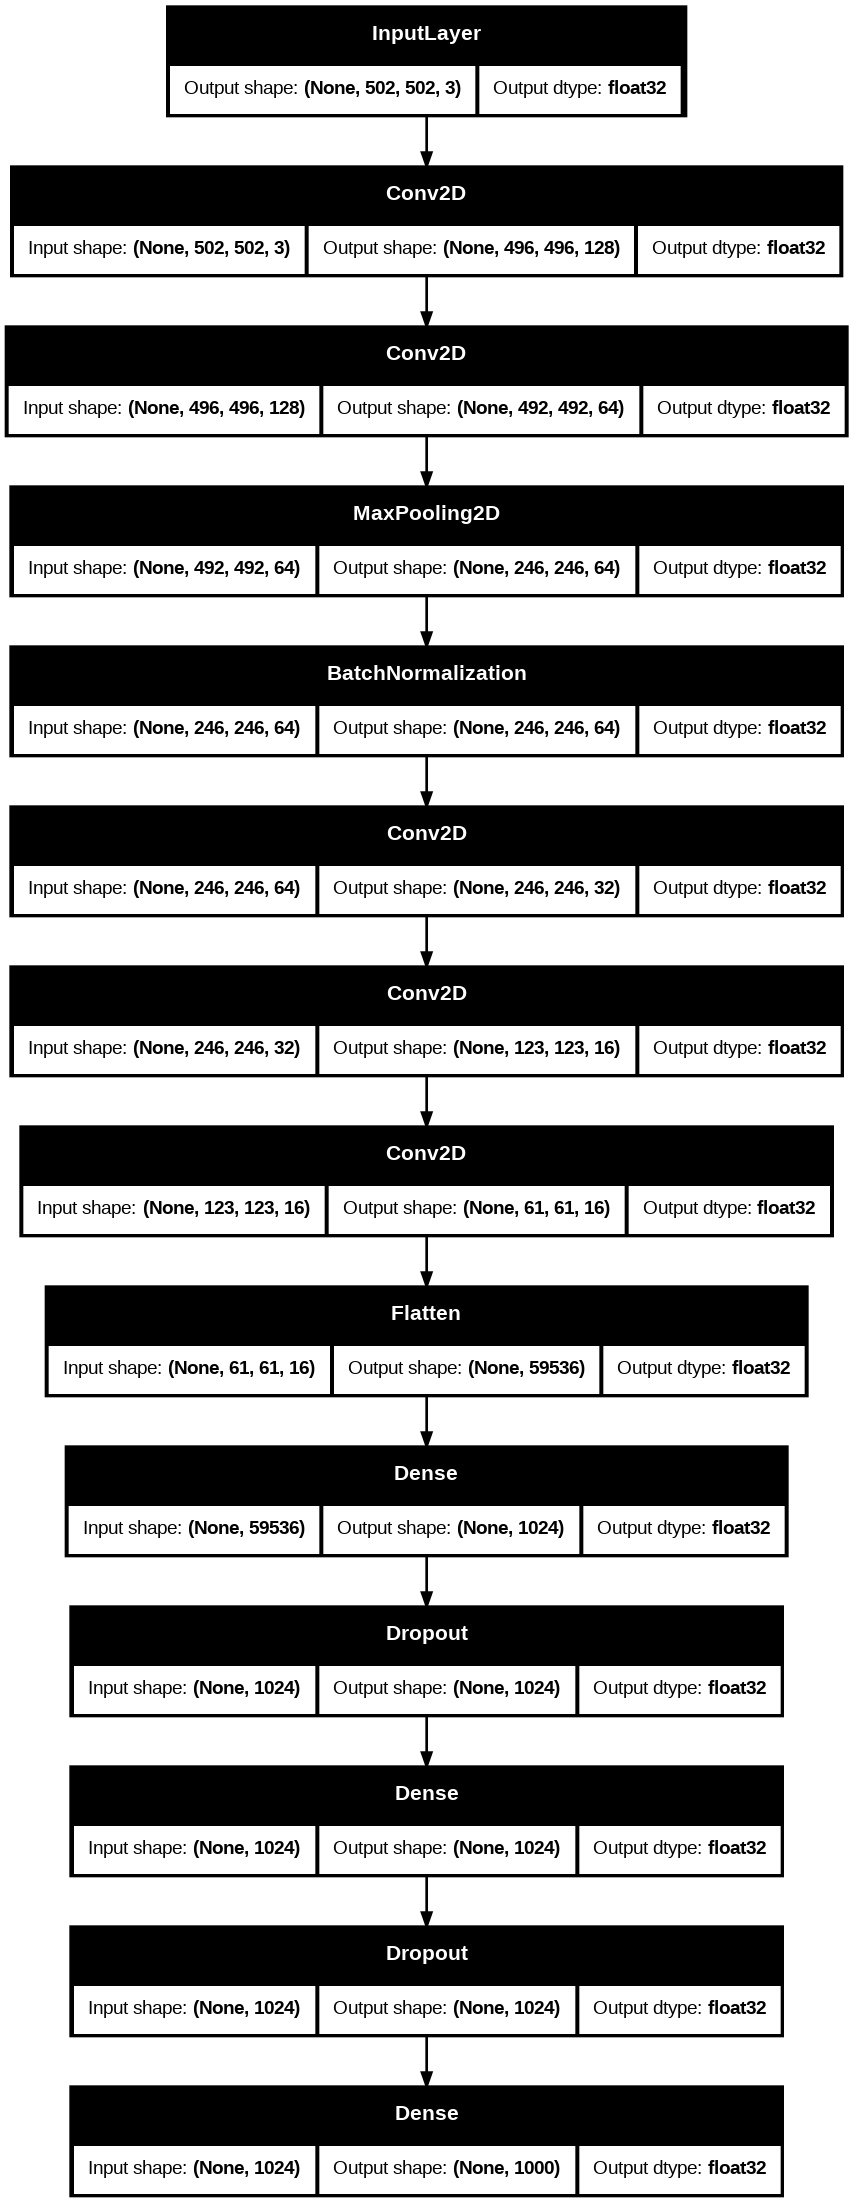

In [7]:
keras.utils.plot_model(model2, to_file='cnn1_functional.png', show_shapes=True, show_dtype=True, show_layer_names=False, dpi=96)

# 3. Test using the models (with random inputs)

In [8]:
# Create one batch of random input data
batch_size = 7
x = np.random.rand( batch_size, *input_dim ).astype(np.float32)

print( f"x.shape={x.shape} , x.dtype={x.dtype} , min(x)={np.min(x):.4f} , max(x)={np.max(x):.4f}" )

x.shape=(7, 502, 502, 3) , x.dtype=float32 , min(x)=0.0000 , max(x)=1.0000


In [9]:
%%time

# Pass the data to model1 (created by Sequential API)
y_pred1 = model1.predict( x )
print( f"y_pred1.shape={y_pred1.shape} , y_pred1.dtype={y_pred1.dtype} , min(y_pred1)={np.min(y_pred1):.4f} , max(y_pred1)={np.max(y_pred1):.4f}" )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
y_pred1.shape=(7, 1000) , y_pred1.dtype=float32 , min(y_pred1)=0.0009 , max(y_pred1)=0.0011
CPU times: user 310 ms, sys: 146 ms, total: 456 ms
Wall time: 1.2 s


In [10]:
%%time

# Pass the data to model2 (created by Functional API)
y_pred2 = model2.predict( x )
print( f"y_pred2.shape={y_pred2.shape} , y_pred2.dtype={y_pred2.dtype} , min(y_pred2)={np.min(y_pred2):.4f} , max(y_pred2)={np.max(y_pred2):.4f}" )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
y_pred2.shape=(7, 1000) , y_pred2.dtype=float32 , min(y_pred2)=0.0009 , max(y_pred2)=0.0011
CPU times: user 259 ms, sys: 8.83 ms, total: 268 ms
Wall time: 267 ms
